# Task 4 -- Location-Based Analysis
### Restaurant Intelligence Suite | Cognifyz Technologies ML Internship

## 1. Introduction
This notebook analyzes restaurant distribution, pricing, and ratings across geography --
cities, localities, and coordinates -- and produces interactive maps for business exploration.

## 2. Business Problem
Expansion and marketing teams need to know: which cities are saturated, which are emerging
markets, where premium dining clusters, and where affordable-but-highly-rated restaurants exist.

## 3. Objective
Quantify city/locality-level restaurant density, pricing, and rating patterns, and produce
interactive Folium maps (marker clusters, heatmaps) supporting geographic business insight.


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster, HeatMap

from utils import load_dataset, dataset_summary, set_plot_style, save_fig
from preprocessing import clean_dataset, cap_outliers
from feature_engineering import build_feature_set

set_plot_style()


## 4. Dataset Understanding & 5. Data Cleaning

In [2]:
df_raw = load_dataset('../data/restaurant_dataset.csv')
df = clean_dataset(df_raw)
df = build_feature_set(df)
df = cap_outliers(df, 'Average Cost for two')

# Drop rows with invalid (0,0) coordinates -- these are missing GPS data, not real locations
before = len(df)
df = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)]
print(f"Dropped {before - len(df)} rows with missing (0,0) coordinates.")
print(f"Usable geo-tagged restaurants: {len(df)}")


Capped 118 outliers in 'Average Cost for two' to [10.0, 3400.0].
Dropped 499 rows with missing (0,0) coordinates.
Usable geo-tagged restaurants: 9052


## 6. Exploratory Data Analysis -- City & Locality Patterns

In [3]:
city_summary = df.groupby('City').agg(
    restaurant_count=('Restaurant ID', 'count'),
    avg_rating=('Aggregate rating', 'mean'),
    avg_cost=('Average Cost for two', 'mean'),
    avg_votes=('Votes', 'mean')
).sort_values('restaurant_count', ascending=False)

print("Top 10 cities by restaurant count:")
city_summary.head(10)


Top 10 cities by restaurant count:


,restaurant_count,avg_rating,avg_cost,avg_votes
City,,,,
New Delhi,5240,2.502061,590.446565,119.639695
Gurgaon,1070,2.721963,725.373832,123.265421
Noida,986,2.165112,551.419878,74.210953
Faridabad,229,1.991703,451.310044,28.034934
Ghaziabad,25,2.852000,602.000000,94.640000
Ahmedabad,21,4.161905,857.142857,584.095238
Augusta,20,4.130000,27.000000,395.450000
Cedar Rapids/Iowa City,20,4.165000,25.750000,332.300000
Chennai,20,4.315000,1085.000000,1384.750000


Figure saved -> ../outputs/figures/task4_top_cities_count.png


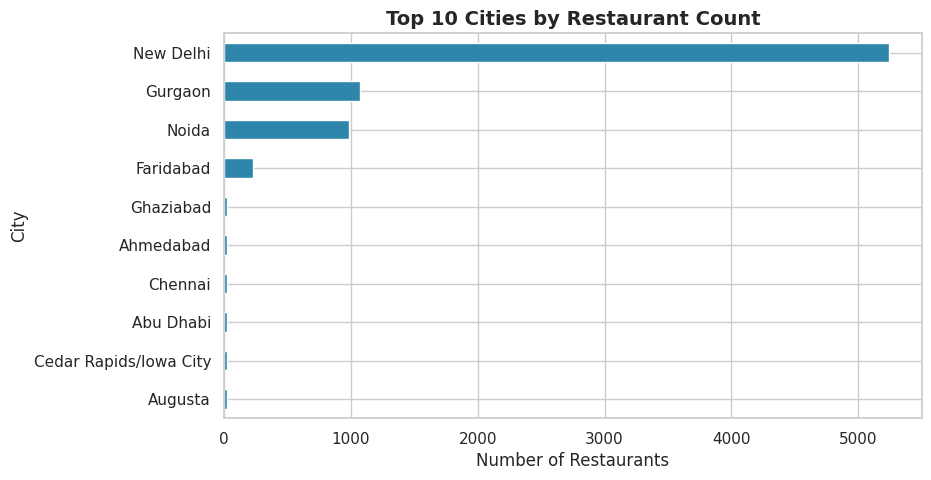

In [4]:
fig, ax = plt.subplots(figsize=(9,5))
city_summary['restaurant_count'].head(10).sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 10 Cities by Restaurant Count')
ax.set_xlabel('Number of Restaurants')
save_fig(fig, 'task4_top_cities_count')
plt.show()


**Insight:** Restaurant listings are heavily concentrated in a small number of metro cities, with New Delhi and the National Capital Region dominating -- indicating this dataset's coverage is India-centric even though it spans 15 countries.

Figure saved -> ../outputs/figures/task4_top_cities_rating.png


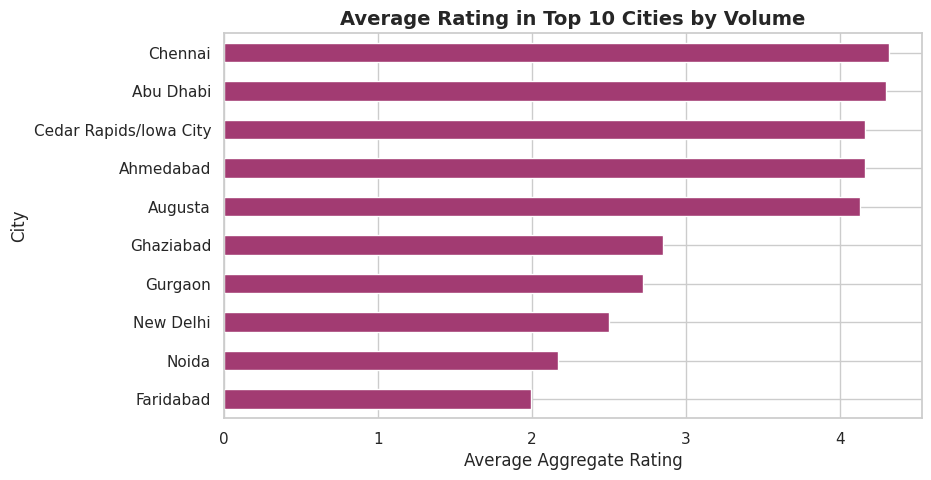

In [5]:
fig, ax = plt.subplots(figsize=(9,5))
top10_by_count = city_summary.head(10)
top10_by_count['avg_rating'].sort_values().plot(kind='barh', ax=ax, color='#A23B72')
ax.set_title('Average Rating in Top 10 Cities by Volume')
ax.set_xlabel('Average Aggregate Rating')
save_fig(fig, 'task4_top_cities_rating')
plt.show()


**Insight:** Restaurant volume and average rating are not the same thing -- some high-volume cities post below-average ratings, flagging them as markets with room for quality improvement despite dense supply.

In [6]:
locality_summary = df.groupby('Locality').agg(
    restaurant_count=('Restaurant ID', 'count'),
    avg_rating=('Aggregate rating', 'mean'),
    avg_cost=('Average Cost for two', 'mean')
).sort_values('restaurant_count', ascending=False)

print("Top 10 localities by restaurant count:")
locality_summary.head(10)


Top 10 localities by restaurant count:


,restaurant_count,avg_rating,avg_cost
Locality,,,
Connaught Place,122,3.686885,1161.885246
Rajouri Garden,98,3.589796,843.367347
Malviya Nagar,85,3.428235,635.294118
Defence Colony,85,3.208235,746.470588
Pitampura,83,2.853012,451.204819
Shahdara,81,1.518519,288.888889
Rajinder Nagar,79,3.017722,445.822785
Satyaniketan,75,3.494667,542.000000
Karol Bagh,75,3.065333,510.666667


Figure saved -> ../outputs/figures/task4_expensive_cities.png


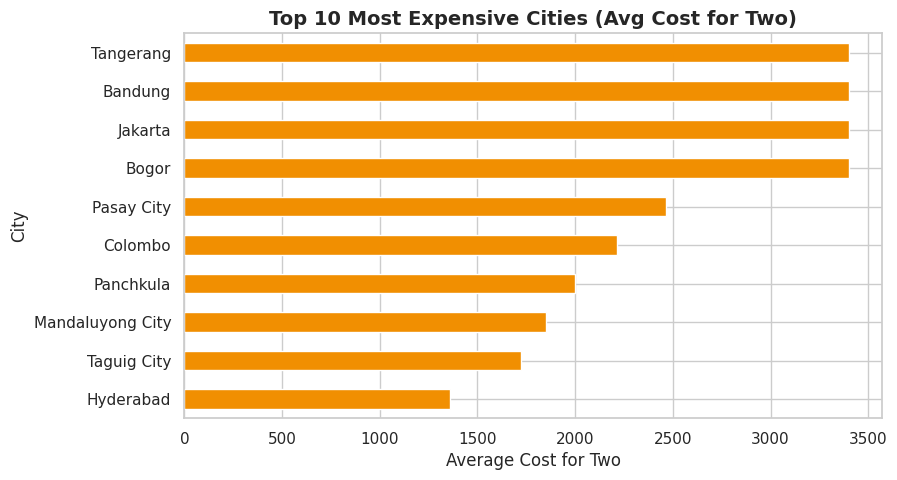

In [7]:
fig, ax = plt.subplots(figsize=(9,5))
df.groupby('City')['Average Cost for two'].mean().sort_values(ascending=False).head(10).sort_values().plot(
    kind='barh', ax=ax, color='#F18F01')
ax.set_title('Top 10 Most Expensive Cities (Avg Cost for Two)')
ax.set_xlabel('Average Cost for Two')
save_fig(fig, 'task4_expensive_cities')
plt.show()


**Insight:** The most expensive cities by average cost-for-two are largely distinct from the highest-volume cities, pointing to premium/niche markets worth targeting for high-margin restaurant partnerships rather than volume-based ones.

In [8]:
cuisine_by_city = df.groupby('City')['Primary Cuisine'].agg(lambda x: x.value_counts().idxmax())
print("Dominant primary cuisine in the top 10 cities by volume:")
cuisine_by_city.loc[city_summary.head(10).index]


Dominant primary cuisine in the top 10 cities by volume:


City
New Delhi                 North Indian
Gurgaon                   North Indian
Noida                     North Indian
Faridabad                 North Indian
Ghaziabad                 North Indian
Ahmedabad                 North Indian
Augusta                       American
Cedar Rapids/Iowa City        American
Chennai                   North Indian
Abu Dhabi                       Indian
Name: Primary Cuisine, dtype: str

## 7. Feature Engineering -- City-Level Aggregates

In [9]:
df['is_premium'] = df['Price range'] >= 3
df['is_high_rated'] = df['Aggregate rating'] >= 4.0
df['is_affordable_high_rated'] = (df['Price range'] <= 2) & (df['Aggregate rating'] >= 4.0)
print(f"Affordable + high-rated restaurants: {df['is_affordable_high_rated'].sum()} "
      f"({df['is_affordable_high_rated'].mean():.1%} of geo-tagged restaurants)")


Affordable + high-rated restaurants: 555 (6.1% of geo-tagged restaurants)


## 8-9. Interactive Maps (Folium)

In [10]:
# Restaurant density map with marker clustering -- sampled for rendering performance
sample_df = df.sample(min(1500, len(df)), random_state=42)
center_lat, center_lon = df['Latitude'].median(), df['Longitude'].median()

density_map = folium.Map(location=[center_lat, center_lon], zoom_start=2, tiles='CartoDB positron')
cluster = MarkerCluster().add_to(density_map)

for _, row in sample_df.iterrows():
    popup_text = (f"<b>{row['Restaurant Name']}</b><br>"
                  f"City: {row['City']}<br>"
                  f"Cuisine: {row['Cuisines']}<br>"
                  f"Rating: {row['Aggregate rating']} | Cost for two: {row['Average Cost for two']}")
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_text, max_width=250),
        icon=folium.Icon(color='blue', icon='cutlery', prefix='fa')
    ).add_to(cluster)

os.makedirs('../outputs/reports', exist_ok=True)
density_map.save('../outputs/reports/task4_restaurant_density_map.html')
print("Saved: outputs/reports/task4_restaurant_density_map.html")
density_map


Saved: outputs/reports/task4_restaurant_density_map.html


In [11]:
# Rating heatmap -- weighted by aggregate rating to highlight quality clusters
heat_data = df[df['Aggregate rating'] > 0][['Latitude', 'Longitude', 'Aggregate rating']].values.tolist()

rating_heatmap = folium.Map(location=[center_lat, center_lon], zoom_start=2, tiles='CartoDB dark_matter')
HeatMap(heat_data, radius=8, blur=6, max_zoom=6).add_to(rating_heatmap)

rating_heatmap.save('../outputs/reports/task4_rating_heatmap.html')
print("Saved: outputs/reports/task4_rating_heatmap.html")
rating_heatmap


Saved: outputs/reports/task4_rating_heatmap.html


**Insight:** Both maps are saved as standalone interactive HTML files in `outputs/reports/` so they can be opened directly in a browser or embedded in a project README/portfolio page outside the notebook environment.

## 10. Business Insights
- **Best cities (volume + quality):** cities that combine high restaurant counts with
  above-average ratings are the strongest candidates for continued platform investment.
- **Emerging markets:** cities with modest restaurant counts but high average ratings signal
  under-served, high-quality markets worth expansion focus before competitors saturate them.
- **Premium locations:** the highest-average-cost cities/localities identify where fine-dining
  partnerships and premium advertising placements would command the most value.
- **Affordable, high-rated regions:** localities with many restaurants in price range 1-2 that
  still average 4.0+ ratings are the platform's best "value" story for price-sensitive users.
- **High-rated areas:** rating hot-spots visible on the heatmap point to neighborhoods with a
  strong dining culture worth featuring in curated city guides.

## 11. Conclusion
Restaurant supply, pricing, and quality vary substantially by geography and are only loosely
coupled -- high volume does not imply high quality, and high cost does not imply high rating.
Geographic segmentation (city/locality) is therefore essential context for any rating-prediction
or recommendation feature built on this dataset, which is why `City` and `Locality` were
retained as first-class features throughout Tasks 1-3.

## 12. Future Improvements
- Enrich with external demographic/income data per city to explain premium/affordable clustering.
- Add drive/walk-time isochrone analysis for locality-level competitive density.
- Build a live-updating dashboard (e.g. Streamlit/Plotly Dash) on top of these aggregates for
  non-technical business stakeholders.
